## Importing necessary libraries and functions

In [2]:
from tomograph_functions import radon_transform,back_projection,filtr_sinogram
from helpers import normalize_img,show_img
from dicom_functions import save_dicom_file,read_dicom_file
import numpy as np
import os
import ipywidgets.widgets as widgets
import datetime
from sklearn.metrics import root_mean_squared_error
import ipywidgets as widgets
from IPython.display import display
from IPython.display import display
import matplotlib.pyplot as plt
import warnings
import threading
#Supressing warrnigns
warnings.filterwarnings("ignore")

### Selecting the input image and set options of simulation

In [3]:
available_images=[file.name for file in os.scandir("./tomograf-dicom") if file.is_file()]

detectors=widgets.IntSlider(
    value=180,
    min=21,
    max=360,
    step=1,
    description='Detectors:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='auto')
)
detectors_spread=widgets.FloatSlider(
    value=90.0,
    min=45.0,
    max=270,
    step=0.5,
    description='Angular spread:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
    layout=widgets.Layout(width='auto')
)

step=widgets.FloatSlider(
    value=1.0,
    min=0.1,
    max=10.0,
    step=0.1,
    description='Step value:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
    layout=widgets.Layout(width='auto')
)

cbox=widgets.Combobox(

    placeholder='Choose an image',
    options=available_images,
    description='Combobox:',
    ensure_option=True,
    disabled=False,
    layout=widgets.Layout(width='auto')
)
filtering=widgets.Checkbox(
    value=True,
    description='Use filtering',
    disabled=False,
    layout=widgets.Layout(width='auto')
)
show_steps=widgets.Checkbox(
    value=False,
    description='Show steps',
    disabled=False,
    layout=widgets.Layout(width='auto')
)
sliders=widgets.VBox([detectors,detectors_spread,step,cbox,filtering,show_steps],layout=widgets.Layout(width='45%'))
display(sliders)

### Displaying patient data

In [5]:
if cbox.value != "":
    image,data = read_dicom_file(f"tomograf-dicom/{cbox.value}")
    #PARAMETERS:list[str]=["Name","ID","Sex","Age","Study Date","Comments"]
    widgets_to_show:list=[]
    for parameter,value in data.items():
        text=value if value!="" else "No data "
        
        if "^" in text:
            text=" ".join(text.split("^"))
        if "Comments" in parameter:
            widgets_to_show.append(widgets.Textarea(description=f"{parameter.replace("Image","")}:", value=f"{text}",disabled=True))
            continue
        widgets_to_show.append(widgets.Text(description=f"{parameter.replace("Patient","").replace("Study","Study ")}:", value=f"{text}",disabled=True))

    display(widgets.VBox(widgets_to_show,layout=widgets.Layout(width='85%')))

    

### Radon transform and back projection

In [7]:
final=None

if cbox.value != "":
    height, width = image.shape

    intermediate_sinograms, sinogram = radon_transform(
        image, detectors.value, step.value, detectors_spread.value
    )

    filtered_str = ""
    if filtering.value:
        sinogram = filtr_sinogram(sinogram)
        filtered_str = " (with filtering)"
        intermediate_sinograms = [filtr_sinogram(part_sin) for part_sin in intermediate_sinograms]

    intermediate_reconstructed, final = back_projection(
        sinogram, height, width, detectors.value, step.value, detectors_spread.value
    )
    final=normalize_img(final)
    intermediate_reconstructed=[normalize_img(recon) for recon in intermediate_reconstructed]

    input_image_out = widgets.Output()
    with input_image_out:
        show_img(image, title="Input image")

    final_sinogram_out = widgets.Output()
    with final_sinogram_out:
        show_img(sinogram, title=f"Sinogram{filtered_str}")

    final_image_out = widgets.Output()
    with final_image_out:
        show_img(final, title=f"Final image{filtered_str}")

    images_box = widgets.HBox([input_image_out, final_sinogram_out, final_image_out])
    display(images_box)
    

KeyboardInterrupt: 

In [ ]:
#Wrappers for show_img to make interactive dispaying
if show_steps.value:
    def show_sinogram(step: int) -> None:
        show_img(intermediate_sinograms[step], title=f"Sinogram {filtered_str} number {step}")

    def show_reconstructed(step:int)->None:
        show_img(intermediate_reconstructed[step], title=f"Reconstructed {filtered_str} number {step}")

    slider_sinogram = widgets.IntSlider(
        min=0,
        max=len(intermediate_sinograms) - 1,
        step=1,
        value=0
        #interval=100
    )

    slider_reconstructed = widgets.IntSlider(#widgets.Play(
        min=0,
        max=len(intermediate_reconstructed) - 1,
        step=1,
        value=0,
        interval=100
    )

    part_sinogram = widgets.interactive_output(show_sinogram, {'step': slider_sinogram})
    part_reconstructed=widgets.interactive_output(show_reconstructed,{'step': slider_reconstructed})


    sliders = widgets.HBox([slider_sinogram,slider_reconstructed])
    part_images=widgets.HBox([part_sinogram,part_reconstructed])
    combined=widgets.VBox([sliders,part_images])
    display(combined)

### Adding the examination data

In [7]:
if cbox.value != "" and final is not None:
        patient_name=widgets.Textarea(description="Name", placeholder="Enter last name and first name (separated by a space)",disabled=False)
        patient_id=widgets.Text(description="ID", placeholder="Enter patient id",disabled=False)

        patient_sex=widgets.Combobox(
                placeholder='Choose a gender',
                options=["M","O","F"],
                description="Sex",
                ensure_option=True,
                disabled=False,
                layout=widgets.Layout(width='auto')
        )

        age_format=widgets.Combobox(
                placeholder='Choose age format',
                options=["M","W","Y"],
                description="Age format",
                ensure_option=True,
                disabled=False,
                layout=widgets.Layout(width='auto')
        )
        patient_age=widgets.IntSlider(
                description="Age value",
                min=1,
                max=130,
                step=1,
                value=0
                )
        
        examination_date=widgets.DatePicker(
        description='Study Date',
        disabled=False,
        layout=widgets.Layout(width='auto')
        )
        comments=widgets.Textarea(description="Comments", placeholder="Enter Comments",disabled=False,layout=widgets.Layout(width='auto'))
    
        widgets_to_show=[patient_name,patient_id,patient_sex,age_format,patient_age,examination_date,comments]
        display(widgets.VBox(widgets_to_show,layout=widgets.Layout(width='30%')))

### Saving the examination data

In [61]:
if cbox.value != "" and final is not None:
    current_time=datetime.datetime.now()
    cr_year=current_time.year
    cr_month=current_time.month
    cr_day=current_time.day
    cr_hour=current_time.hour
    cr_min=current_time.minute
    name="^".join(patient_name.value.split()) if patient_name.value else patient_name.value
    study_date=examination_date.value if examination_date.value is not None else "No Date given"
    
    if study_date!="No Date given":
        study_date="".join(str(study_date).split("-")[::-1])



    if age_format.value!="":
        age=f"{"0"*(3-len(str(patient_age.value)))}{patient_age.value}{age_format.value}"
    else:
        age=""
    
    try:
        save_dicom_file(f"./{cbox.value}_updated_{cr_year}_{cr_month}_{cr_day}_{cr_hour}_{cr_min}.dcm",
                        final,name,patient_id.value,patient_sex.value,
                        age,study_date,comments.value)
    except Exception as e:
        print(f"Exception occured: {e}")
    

## Satistic analysis

### RMSE between the input image and the intermediates reconstructed images (without filtering)

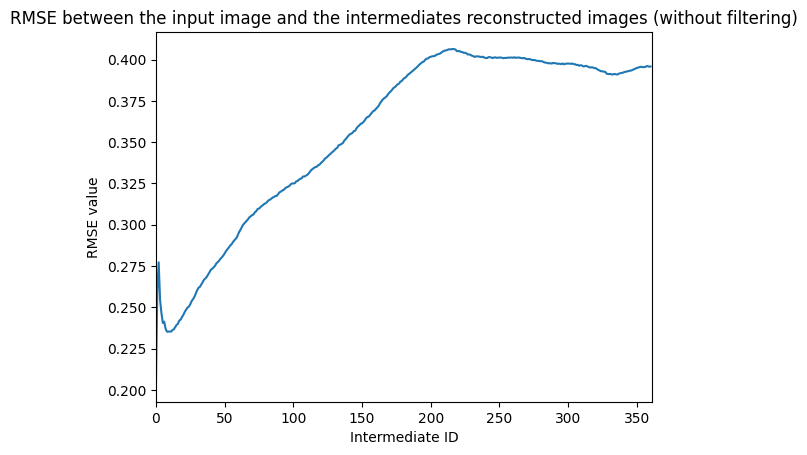

In [8]:

intermediate_sinograms, sinogram = radon_transform(
        image, detectors.value, step.value, detectors_spread.value
    )
intermediate_reconstructed, final = back_projection(
        sinogram, height, width, detectors.value, step.value, detectors_spread.value
    )
final=normalize_img(final)
intermediate_reconstructed=[normalize_img(recon) for recon in intermediate_reconstructed]

results:list[float]=[]
for partial_recon in intermediate_reconstructed:
    normalized_img=normalize_img(image)
    results.append(root_mean_squared_error(normalized_img,partial_recon))
x=list(range(0,len(results)))
plt.plot(x,results)
plt.title("RMSE between the input image and the intermediates reconstructed images (without filtering)")
plt.xlabel("Intermediate ID")
plt.xlim(0,len(intermediate_reconstructed))
plt.ylabel("RMSE value")
plt.show()


### RMSE between filtered final images and the input, with increasing precision

In [ ]:


# normalize once, before threads
normalized_img = normalize_img(image)

# result lists
changing_detectors = []
changing_step = []
changing_spread = []

# locks
detectors_lock = threading.Lock()
step_lock = threading.Lock()
spread_lock = threading.Lock()


def multithread_radon_transform(
    image: np.ndarray,
    parameter: str,
    parameter_value: int | float
) -> None:
    height, width = image.shape
    #Default values for testing
    #Detectors: 180
    #Scans: 180 <-> step=2
    #Spread: 180
    if parameter == "detectors":
        _, sinogram = radon_transform(image, parameter_value, 2, 180)
        _, final = back_projection(
            filtr_sinogram(sinogram.copy()),
            height, width,
            parameter_value, 2, 180
        )
        final_normalized = normalize_img(final)
        result = root_mean_squared_error(normalized_img, final_normalized)

        with detectors_lock:
            changing_detectors.append((parameter_value, result,final_normalized.copy()))
        return

    if parameter == "step":
        _, sinogram = radon_transform(image, 180, parameter_value, 180)
        _, final = back_projection(
            filtr_sinogram(sinogram.copy()),
            height, width,
            180, parameter_value, 180
        )
        final_normalized = normalize_img(final)
        result = root_mean_squared_error(normalized_img, final_normalized)

        with step_lock:
            changing_step.append((parameter_value, result,final_normalized.copy()))
        return

    if parameter == "spread":
        _, sinogram = radon_transform(image, 180, 2, parameter_value)
        _, final = back_projection(
            filtr_sinogram(sinogram.copy()),
            height, width,
            180, 2, parameter_value
        )
        final_normalized = normalize_img(final)
        result = root_mean_squared_error(normalized_img, final_normalized)

        with spread_lock:
            changing_spread.append((parameter_value, result,final_normalized.copy()))
        return


threads = []

for step_val in range(90, 721,90):
    th = threading.Thread(
        target=multithread_radon_transform,
        args=(image, "detectors", step_val)
    )
    threads.append(th)
    th.start()

for th in threads:
    th.join()

threads = []

for step_val in range(1,9,1):
    th = threading.Thread(
        target=multithread_radon_transform,
        args=(image, "step", 4.0/step_val)
    )
    threads.append(th)
    th.start()

for th in threads:
    th.join()

threads = []

for spread_val in range(45,271,45):
    th = threading.Thread(
        target=multithread_radon_transform,
        args=(image, "spread", spread_val)
    )
    threads.append(th)
    th.start()

for th in threads:
    th.join()



print(changing_detectors)
print(changing_step)
print(changing_spread)
    

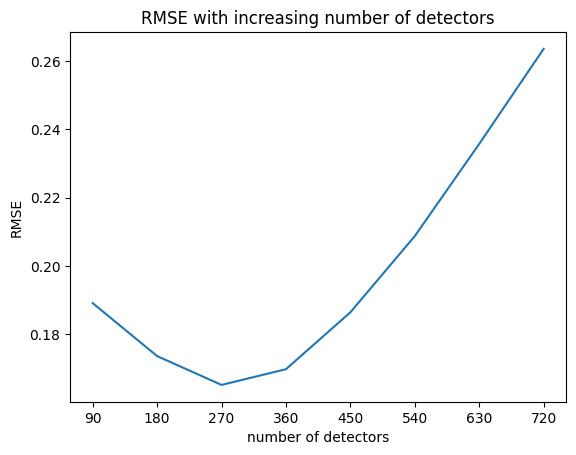

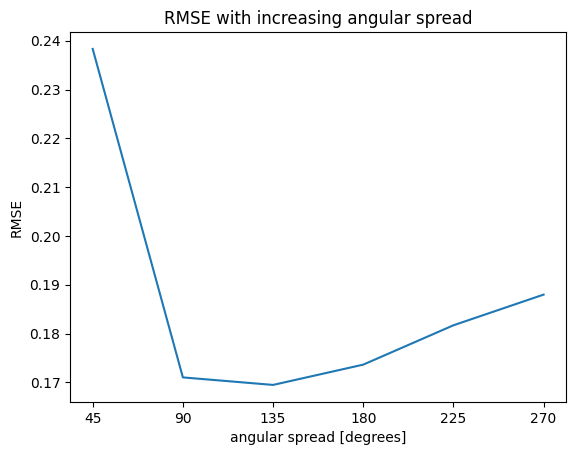

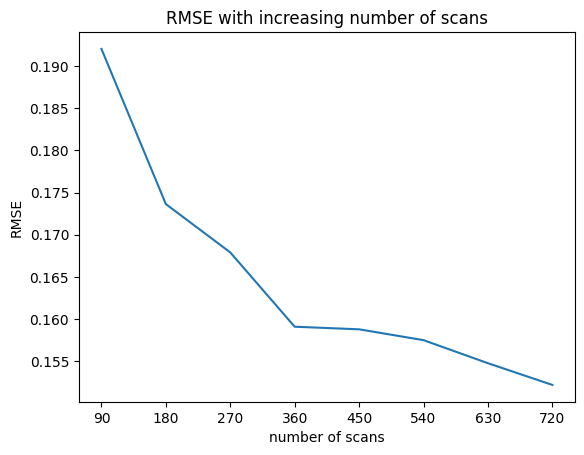

In [ ]:
changing_detectors.sort(key=lambda x:x[0])
changing_spread.sort(key=lambda x:x[0])
changing_step.sort(key=lambda x:x[0])
#Transforming form step vaule to number of scans
for i in range(len(changing_step)):
    changing_step[i]=(360.0/changing_step[i][0],changing_step[i][1],changing_step[i][2])


plt.plot([changing_detectors[i][0] for i in range(len(changing_detectors))],[changing_detectors[i][1] for i in range(len(changing_detectors))])
plt.title("RMSE with increasing number of detectors")
plt.xlabel("number of detectors")
plt.xticks(list(range(90,721,90)))
plt.ylabel("RMSE")
plt.show()

plt.plot([changing_spread[i][0] for i in range(len(changing_spread))],[changing_spread[i][1] for i in range(len(changing_spread))])
plt.title("RMSE with increasing angular spread")
plt.xlabel("angular spread [degrees]")
plt.xticks(list(range(45,271,45)))
plt.ylabel("RMSE")
plt.show()
plt.plot([changing_step[i][0] for i in range(len(changing_step))],[changing_step[i][1] for i in range(len(changing_step))])
plt.title("RMSE with increasing number of scans")
plt.xlabel("number of scans")
plt.xticks(list(range(90,721,90)))
plt.ylabel("RMSE")
plt.show()


In [44]:


def show_detectors(step: int) -> None:
    show_img(changing_detectors[step][2], title=f"Value ID: {step}")

def show_scans(step:int)->None:
    show_img(changing_step[step][2], title=f"Value ID: {step}")

def show_spread(step:int)->None:
    show_img(changing_spread[step][2], title=f"Value ID: {step}")

slider_detectors = widgets.IntSlider(
    min=0,
    max=len(changing_detectors) - 1,
    step=1,
    value=0
    #interval=100
)

slider_scans = widgets.IntSlider(
    min=0,
    max=len(changing_step) - 1,
    step=1,
    value=0
)

slider_spread = widgets.IntSlider(
    min=0,
    max=len(changing_spread) - 1,
    step=1,
    value=0
)

part_detectors = widgets.interactive_output(show_detectors, {'step': slider_detectors})
part_scans=widgets.interactive_output(show_scans,{'step': slider_scans})
part_spred=widgets.interactive_output(show_spread,{'step': slider_spread})


sliders = widgets.HBox([slider_detectors,slider_scans,slider_spread])
part_images=widgets.HBox([part_detectors,part_scans,part_spred])
combined=widgets.VBox([sliders,part_images])
display(combined)

### RMSE between the input image and the intermediates reconstructed images with and without filtering

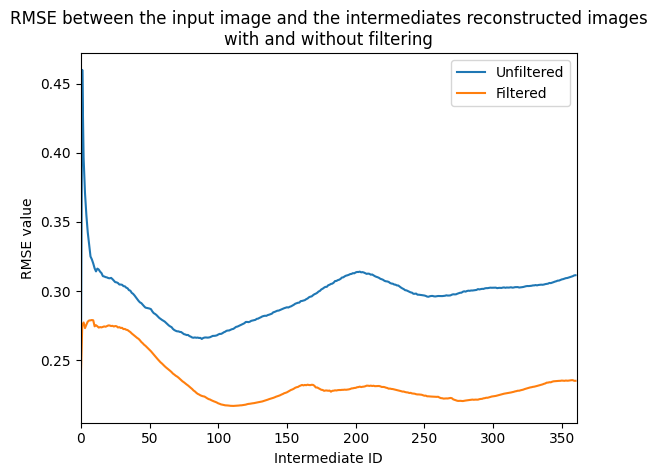

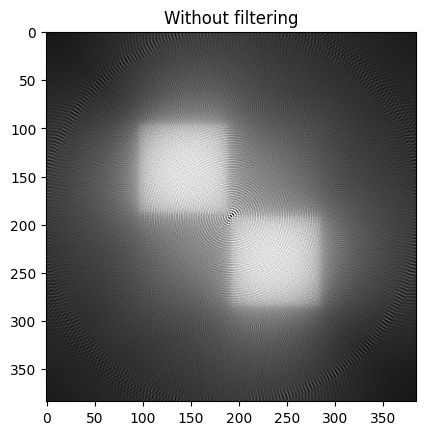

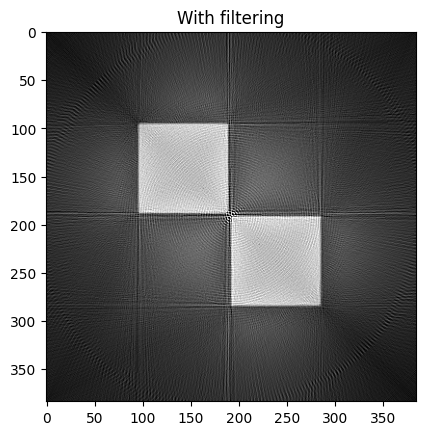

In [8]:
intermediate_sinograms, sinogram = radon_transform(
        image, detectors.value, step.value, detectors_spread.value
    )
height,width=image.shape


intermediate_reconstructed, final = back_projection(
        sinogram, height, width, detectors.value, step.value, detectors_spread.value
    )
final=normalize_img(final)
intermediate_reconstructed=[normalize_img(recon) for recon in intermediate_reconstructed]

intermediate_reconstructed_filtered, final_filtered = back_projection(
        filtr_sinogram(sinogram.copy()), height, width, detectors.value, step.value, detectors_spread.value
    )
final_filtered=normalize_img(final_filtered)
intermediate_reconstructed_filtered=[normalize_img(recon) for recon in intermediate_reconstructed_filtered]

results:list[float]=[]
results_filtered:list[float]=[]
normalized_img=normalize_img(image)
for i in range(len(intermediate_reconstructed)):
    results.append(root_mean_squared_error(normalized_img,intermediate_reconstructed[i]))
    results_filtered.append(root_mean_squared_error(normalized_img,intermediate_reconstructed_filtered[i]))
x=list(range(0,len(results)))
plt.plot(x,results,label="Unfiltered")
plt.plot(x,results_filtered,label="Filtered")
plt.legend()
plt.title("RMSE between the input image and the intermediates reconstructed images\nwith and without filtering")
plt.xlabel("Intermediate ID")
plt.xlim(0,len(intermediate_reconstructed))
plt.ylabel("RMSE value")
plt.show()
show_img(final,"Without filtering")
show_img (final_filtered,"With filtering")